In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [10]:
df = pd.read_csv('/content/mental_health_social_media_dataset.csv')
df.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [ ]:
df.isnull().sum()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [12]:
unique_platforms_count = df['platform'].nunique()
print(f"Number of unique platforms: {unique_platforms_count}")

unique_platforms = df['platform'].unique()
print("First 10 unique platforms:")
for i, platform in enumerate(unique_platforms[:10]):
    print(f"{i+1}. {platform}")

Number of unique platforms: 7
First 10 unique platforms:
1. Instagram
2. Snapchat
3. Facebook
4. WhatsApp
5. TikTok
6. YouTube
7. Twitter


In [13]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


In [14]:
unique_platforms_count = df['platform'].nunique()
print(f"Number of unique platforms: {unique_platforms_count}")

unique_platforms = df['platform'].unique()
print("First 10 unique platforms:")
for i, platform in enumerate(unique_platforms[:10]):
    print(f"{i+1}. {platform}")

Number of unique platforms: 7
First 10 unique platforms:
1. Instagram
2. Snapchat
3. Facebook
4. WhatsApp
5. TikTok
6. YouTube
7. Twitter


In [16]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


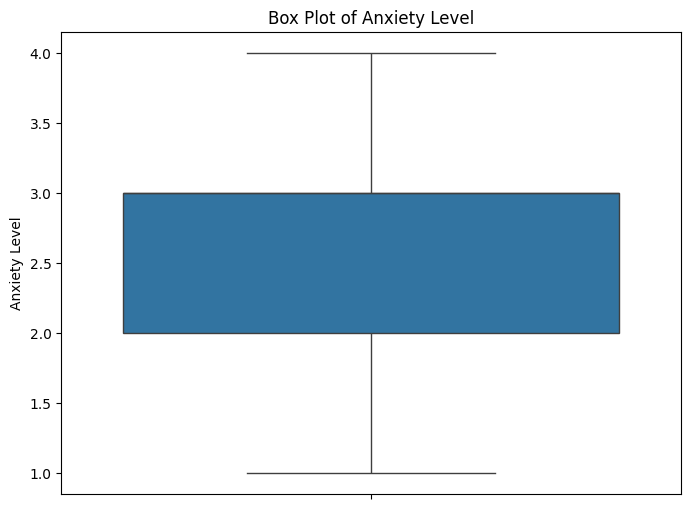

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['anxiety_level'])
plt.ylabel('Anxiety Level')
plt.title('Box Plot of Anxiety Level')
plt.show()

In [18]:
X = df[['daily_screen_time_min', 'social_media_time_min']]
y = df['anxiety_level']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,daily_screen_time_min,social_media_time_min
0,320,160
1,453,226
2,357,196
3,190,105
4,383,211



Target (y) head:


,anxiety_level
0,2
1,3
2,3
3,2
4,3


In [19]:
# The original X only contains numerical columns.
# To one-hot encode a categorical column like 'platform', it needs to be added to X first.
# Assuming the intention was to one-hot encode the 'platform' column.
X = pd.concat([X, df['platform']], axis=1)
X = pd.get_dummies(X, columns=['platform'], drop_first=False)

print("Features (X) after one-hot encoding 'platform':")
display(X.head())

Features (X) after one-hot encoding 'platform':


,daily_screen_time_min,social_media_time_min,platform_Facebook,platform_Instagram,platform_Snapchat,platform_TikTok,platform_Twitter,platform_WhatsApp,platform_YouTube
0,320,160,False,True,False,False,False,False,False
1,453,226,False,True,False,False,False,False,False
2,357,196,False,False,True,False,False,False,False
3,190,105,False,False,True,False,False,False,False
4,383,211,False,False,True,False,False,False,False


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical columns to scale
numerical_cols = ['daily_screen_time_min', 'social_media_time_min']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Features (X) after scaling numerical columns:")
display(X.head())

Features (X) after scaling numerical columns:


,daily_screen_time_min,social_media_time_min,platform_Facebook,platform_Instagram,platform_Snapchat,platform_TikTok,platform_Twitter,platform_WhatsApp,platform_YouTube
0,-0.500581,-0.215325,False,True,False,False,False,False,False
1,0.754215,0.711613,False,True,False,False,False,False,False
2,-0.151502,0.290278,False,False,True,False,False,False,False
3,-1.727073,-0.987773,False,False,True,False,False,False,False
4,0.093796,0.500945,False,False,True,False,False,False,False


In [21]:
from sklearn.model_selection import train_test_split

print("Imported train_test_split successfully.")

Imported train_test_split successfully.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4000, 9)
Shape of X_test: (1000, 9)
Shape of y_train: (4000,)
Shape of y_test: (1000,)


In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=9)

In [25]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train,y_train)

LogisticRegression()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           1       0.98      0.96      0.97       111
           2       0.98      0.98      0.98       378
           3       0.99      1.00      0.99       413
           4       1.00      1.00      1.00        98

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



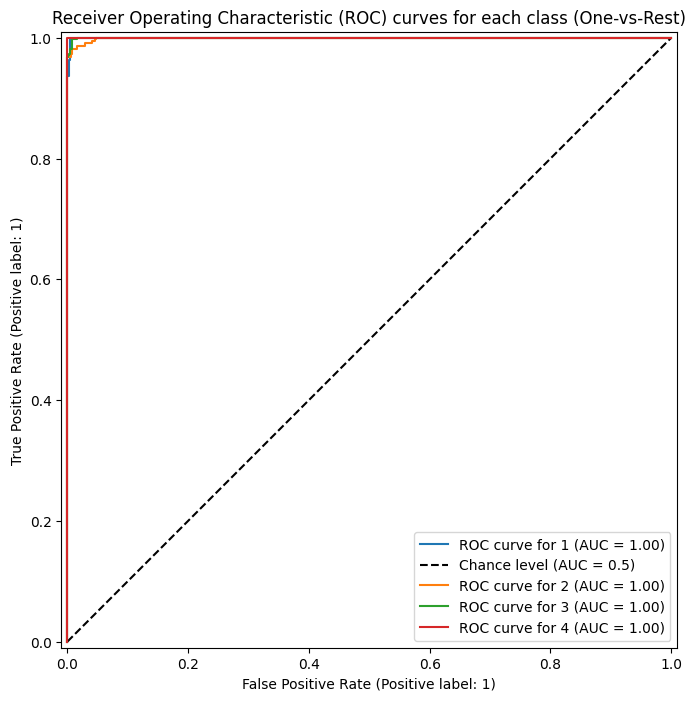

In [29]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay

# Get probabilities for each class
y_score = log_model.predict_proba(X_test)

# Binarize the true labels for one-vs-rest approach
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)
n_classes = len(label_binarizer.classes_)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    class_name = label_binarizer.classes_[i]
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],  # True labels for class i
        y_score[:, i],           # Predicted probabilities for class i
        name=f"ROC curve for {class_name}",
        ax=plt.gca(),
        plot_chance_level=(i == 0) # Plot chance level only once
    )

plt.title('Receiver Operating Characteristic (ROC) curves for each class (One-vs-Rest)')
plt.show()

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=20,p=2)
knn_model.fit(X_train,y_train)
y_pred_train=knn_model.predict(X_train)
y_pred_test=knn_model.predict(X_test)
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))
scores=cross_val_score(knn_model,X,y,cv=5)
scores.mean()

0.995
0.992


np.float64(0.9952)

In [32]:
from sklearn.svm import SVC
model=SVC()
model.fit(X_train,y_train)

SVC()

In [33]:
ypre_train=model.predict(X_train)
ypre_test=model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,ypre_train))
print(accuracy_score(y_test,ypre_test))

0.989
0.986


In [35]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [36]:
y_pred_train = knn_model.predict(X_train)
y_pred_test = knn_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.9985
0.996


In [38]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn_model,X,y,cv=5)
scores.mean()

np.float64(0.9984)

In [39]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train,y_train)

SVC()

In [40]:
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

0.989
0.986


In [43]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=8,random_state=0)
model.fit(X_train,y_train)
ypred_train=model.predict(X_train)
ypred_test=model.predict(X_test)
from sklearn.metrics import accuracy_score
print("train accuracy:",accuracy_score(y_train,ypred_train))
print("test accuracy:",accuracy_score(y_test,ypred_test))

scores=cross_val_score(model,X,y,cv=5)
print("cross validation score:",scores.mean())

train accuracy: 1.0
test accuracy: 1.0
cross validation score: 0.9998000000000001


In [31]:
import numpy as np
df=pd.DataFrame({"algorithm":['Logistic Regression','KNN','SVM','Decision Tree','Random Forest'],
                 "train_accuracy":[0.42,1.32,0.58,0.54,0.22],
                 "test_accuracy":[0.49,0.38,0.12,0.89,0.33],
                 "cv_scores":[1.0,0.66,1.29,0.78,0.77]})
df

,algorithm,train_accuracy,test_accuracy,cv_scores
0,Logistic Regression,0.42,0.49,1.00
1,KNN,1.32,0.38,0.66
2,SVM,0.58,0.12,1.29
3,Decision Tree,0.54,0.89,0.78
4,Random Forest,0.22,0.33,0.77


In [45]:
from joblib import dump

In [46]:
dump(model,'mental_health.joblib')

['mental_health.joblib']